# Poisson-SOR Solver Tutorial

This tutorial demonstrates how to use the three main components of the Poisson-SOR solver:

1. **StructureManager**: Define and manage semiconductor device structures
2. **PoissonSolver**: Solve the 3D Poisson equation using Successive Over-Relaxation (SOR)
3. **Visualizer**: Visualize and analyze the results

## Overview

This project solves the 3D Poisson equation:

$$-\nabla \cdot (\epsilon \nabla \phi) = \rho$$

where:

- φ is the electrostatic potential
- ε is the permittivity (spatially varying)
- ρ is the charge density

We'll solve this for a Si/SiO₂ heterostructure with multiple finger gate electrodes.


## Setup

First, import the necessary modules and set up paths.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add src directory to path
src_path = Path.cwd().parent / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from structure import StructureManager
from potential_interpolator import PotentialInterpolator
from schrodinger import SchrodingerSolver2D
from poisson_solver import PoissonSolver
import visualizer as vis
from visualizer import plot_structure_3d, plot_potential_3d


## Part 1: Structure Definition with StructureManager

As same as `tutorial.ipynb`, we start from loading config by StructureManager:

In [2]:
# Path to configuration file
config_path = Path.cwd().parent / "configs" / "example.yaml"

# Initialize StructureManager and load configuration
print("Loading structure definition...")
manager = StructureManager(str(config_path))

x, y, z = manager.get_grid_coordinates()

# Display structure summary
print("\n" + "=" * 60)
print(manager.get_summary())
print("=" * 60)

Loading structure definition...

=== Structure Summary ===
Grid size (nz, nx, ny): (81, 141, 100)
Grid spacing (h): 1.00 nm (isotropic)
Number of layers: 2
Number of electrodes: 4

--- Unique Materials ---
  0. SiO2: εr=3.90, χ=0.900 eV, Eg=9.000 eV
  1. Si: εr=11.70, χ=4.050 eV, Eg=1.120 eV

--- Layers ---
  1. SiO2: z=[0.0, -25.0] nm
  2. Si: z=[-25.0, -80.0] nm

--- Electrodes ---
  1. gate_1: V=0.000 V, shape=rectangle
  2. gate_2: V=0.500 V, shape=rectangle
  3. gate_3: V=0.000 V, shape=rectangle
  4. gate_4: V=-0.500 V, shape=rectangle


## Part 2: Initialize the interpolator

In [6]:
solver_parameters = {
    "tolerance": 1e-5,
    "max_iterations": 10000,
    "omega": 1.8,
    "use_julia": False,
    "method": "sor"
}

filename = "potinterp_example.npz"
if not Path(filename).exists():
    potinterp = PotentialInterpolator(
        structure_manager=manager,
        z_position=-25e-9,  # 25 nm below surface
        **solver_parameters,
        verbose=2,
    )
    potinterp.save(filename)
else:
    potinterp = PotentialInterpolator.load(filename)

Target z-position: -25.00 nm
Nearest grid point: z_index=25, z=-25.00 nm
Computing basis functions for 4 electrodes...
  [1/2] Computing particular solution (all V=0, ρ≠0)...
      Converged: True, Iterations: 1
  [2/2] Computing 4 basis functions (ρ=0)...
      [1/4] Electrode: gate_1
Iteration 100: Max Δφ = 6.513290e-04
Iteration 200: Max Δφ = 2.101325e-04
Iteration 300: Max Δφ = 8.453218e-05
Iteration 400: Max Δφ = 3.598058e-05
Iteration 500: Max Δφ = 1.581234e-05
      [2/4] Electrode: gate_2
Iteration 100: Max Δφ = 6.638146e-04
Iteration 200: Max Δφ = 2.024583e-04
Iteration 300: Max Δφ = 7.757124e-05
Iteration 400: Max Δφ = 3.236226e-05
Iteration 500: Max Δφ = 1.445785e-05
      [3/4] Electrode: gate_3
Iteration 100: Max Δφ = 6.473081e-04
Iteration 200: Max Δφ = 1.973304e-04
Iteration 300: Max Δφ = 7.529311e-05
Iteration 400: Max Δφ = 3.103088e-05
Iteration 500: Max Δφ = 1.339617e-05
      [4/4] Electrode: gate_4
Iteration 100: Max Δφ = 6.588267e-04
Iteration 200: Max Δφ = 2.06180

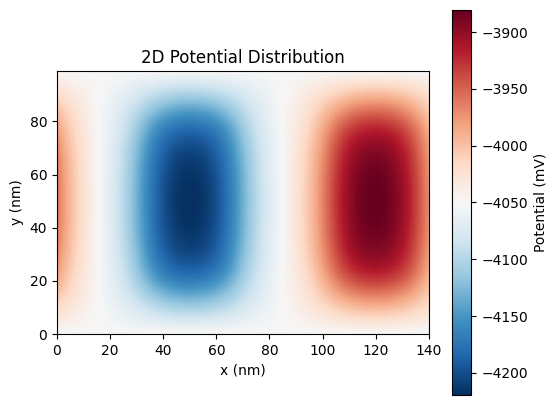

In [4]:
voltages = {
    "gate_1": 0.0,
    "gate_2": 0.5,
    "gate_3": 0.0,
    "gate_4": -0.5,
}

pot2d = potinterp(voltages)
plt.figure(figsize=(6, 5))
im = plt.imshow(
    pot2d.T * 1e3,
    extent=(potinterp.x.min() * 1e9, potinterp.x.max() * 1e9, potinterp.y.min() * 1e9, potinterp.y.max() * 1e9),
    origin="lower",
    cmap="RdBu_r",
)
plt.colorbar(im, label="Potential (mV)")
plt.xlabel("x (nm)")
plt.ylabel("y (nm)")
plt.title("2D Potential Distribution")
plt.show()

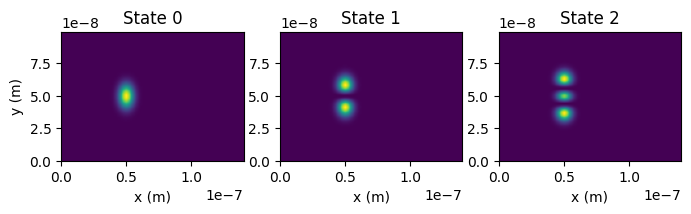

In [5]:
sch = SchrodingerSolver2D(
    potential=pot2d,
    dx=x[1] - x[0],
    dy=y[1] - y[0],
    effective_mass=0.19 * 9.10938356e-31,  # Effective mass for electrons in Si
)
energy, wavefunction = sch.solve(n_states=3)

# Plot the ground state wavefunction
fig, axes = plt.subplots(1, 3, figsize=(8, 4))
for i in range(3):
    axes[i].set_title(f"State {i}")
    im = axes[i].imshow(np.abs(wavefunction[i].T)**2, extent=(x[0], x[-1], y[0], y[-1]), origin='lower')
    axes[i].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
plt.show()


In [6]:
from time_dependent_potential import TimeDependentPotential

freq = 1e6  # 1 MHz

waveform = {
    "gate_1": lambda t: 0.5 * np.sin(2 * np.pi * freq * t),
    "gate_2": lambda t: 0.5 * np.sin(2 * np.pi * freq * t + 0.5*np.pi),
    "gate_3": lambda t: 0.5 * np.sin(2 * np.pi * freq * t + 1.0*np.pi),
    "gate_4": lambda t: 0.5 * np.sin(2 * np.pi * freq * t + 1.5*np.pi),
}

tpot = TimeDependentPotential(
    potential_interpolator=potinterp,
    voltage_functions=waveform
)

Saving animation to: shuttling_animation.gif
Animation saved successfully


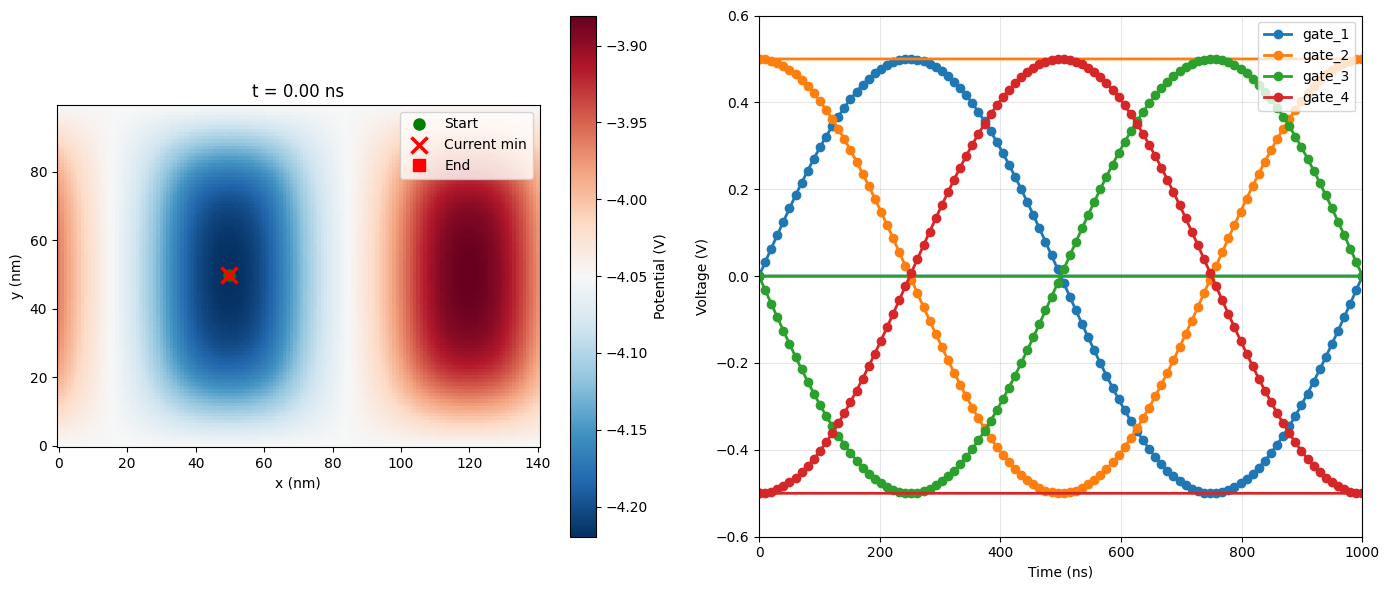

In [7]:
t_array = np.linspace(0, 1e-6, 100)  # 1 microsecond total time

minimum = tpot.track_local_minimum(
    t_array=t_array,
    initial_position=(50e-9, 50e-9),
)

tpot.animate(
    t_array=t_array,
    save_path="shuttling_animation.gif",
    track_minimum=minimum,
    show_trajectory=True,
)

## Part 3: Animate Ground State with Tracking

Now let's animate the ground state wavefunction tracking the local minimum.
This shows how the quantum dot wavefunction evolves as it shuttles along the potential minimum.

Pre-computing potential range...
Solving initial local Schrödinger equation...
Creating animation with 50 frames...
Saving animation to: ground_state_tracking.gif
Animation saved successfully


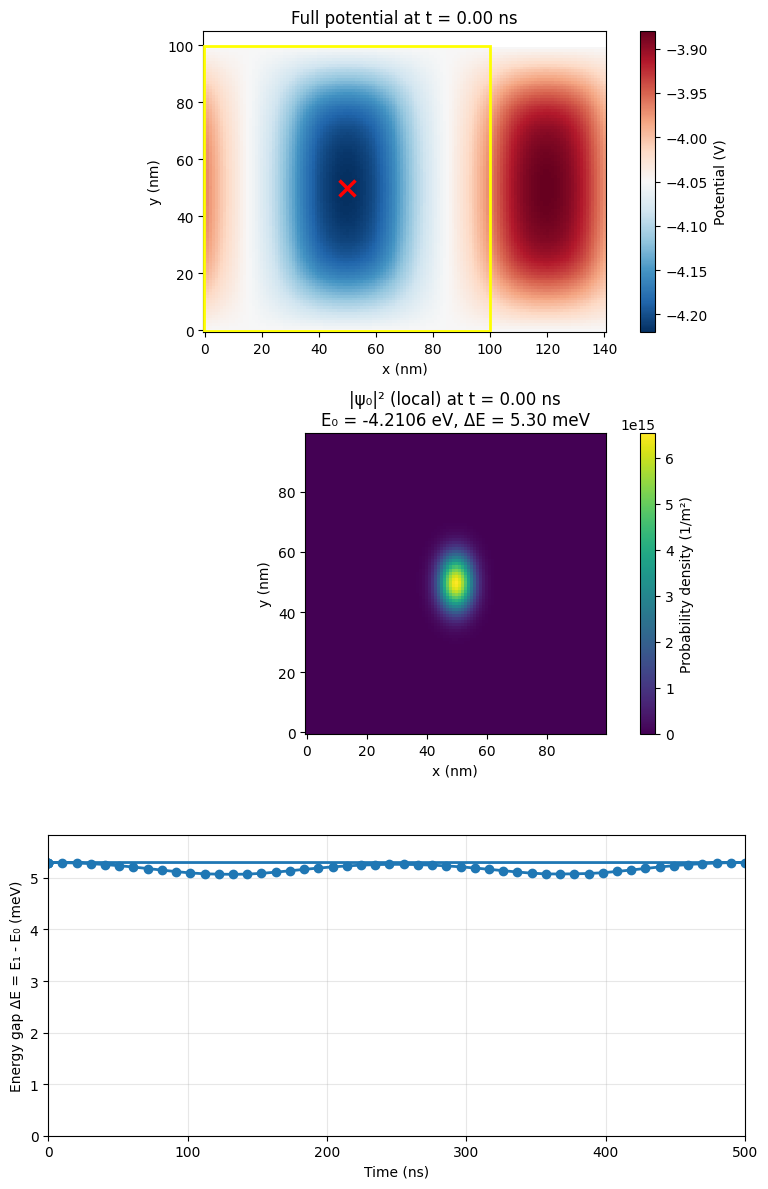

In [8]:
from scipy.constants import electron_mass

# Use a shorter time array for demonstration (fewer frames = faster)
t_array_short = np.linspace(0, 0.5e-6, 50)  # 50 frames over 0.5 microseconds

# Track the local minimum
tracking = tpot.track_local_minimum(
    t_array=t_array_short,
    initial_position=(50e-9, 50e-9),
    effective_mass=0.19 * electron_mass,
)

# Create animation with ground state tracking
# This extracts a local region around the tracked minimum and solves
# the Schrödinger equation in that region at each time step
anim = tpot.animate_ground_state_with_tracking(
    t_array=t_array_short,
    tracking_result=tracking,
    effective_mass=0.19 * electron_mass,
    region_size=100e-9,  # Extract 100nm x 100nm region around minimum
    n_states=2,  # Compute ground state and first excited state
    save_path="ground_state_tracking.gif",
    fps=10,
    show_energy=True,  # Show energy gap ΔE = E₁ - E₀
)

The animation shows three panels:

1. **Top panel**: Full potential landscape with trajectory (red line), current position (red X), and extraction box (yellow square)
2. **Middle panel**: Local probability density |ψ₀|² around the tracked minimum (zoomed view)
3. **Bottom panel**: Energy gap ΔE = E₁ - E₀ between ground state and first excited state vs time

This approach is computationally efficient because it only solves the Schrödinger equation in a small local region around the minimum, rather than over the entire domain.